In [1]:
%matplotlib widget

In [2]:
from pathlib import Path
import h5py
import json

import numpy as np
import pandas as pd
from scipy import signal
import matplotlib.pyplot as plt

In [3]:
class SignalAnnotator:
    def __init__(self, ts, signal, sampling_rate: None | int = None):
        self.ts = self._validate_array(ts, "ts")
        self.signal = self._validate_array(signal, "signal")
        self.sampling_rate = sampling_rate

        if len(self.ts) != len(self.signal):
            raise ValueError(
                f"ts и signal должны иметь одинаковую длину: "
                f"{len(self.ts) != len(self.signal)}"
            )

        # Временные координаты размеченных точек
        self.points = []
        self.anomaly_points = []

        # Matplotlib objects
        self.fig = None
        self.ax = None

        # ID обработчика событий
        self._key_press_cid = None

        # Графические объекты, соответствующие меткам
        self._markers = []
        self._anomaly_markers = []

        self._active = False

    @staticmethod
    def _validate_array(array, name):
        if not isinstance(array, np.ndarray):
            raise TypeError(
                f"{name} должен быть numpy.ndarray, "
                f"получен {type(array).__name__}"
            )

        if len(array) == 0:
            raise ValueError(f"{name} не должен быть пустым")

        return array

    def show_plots(self, figsize=(12, 5)):
        """
        Открыть интерактивную фигуру.

        Для Jupyter Lab перед использованием рекомендуется выполнить:

            %matplotlib widget
        """

        # Если фигура уже существует, не создаём вторую
        if self.fig is not None and plt.fignum_exists(self.fig.number):
            return

        self.fig, self.ax = plt.subplots(
            1,
            1,
            figsize=figsize,
            sharex=False,
            constrained_layout=True,
        )

        self.ax.plot(
            self.ts,
            self.signal,
            linewidth=0.8,
        )

        self.ax.grid(alpha=0.25)

        self._redraw_existing_markers()

        self._active = True

        self._key_press_cid = self.fig.canvas.mpl_connect(
            "key_press_event",
            self._on_key_press,
        )

        plt.show()

    def _on_key_press(self, event):
        if not self._active:
            return
    
        if event.inaxes is None:
            return
    
        if event.key == "a":
            if event.xdata is None:
                return
    
            time = float(event.xdata)
            self._add_point(time)
    
        elif event.key == "u":
            self._remove_last_point()

        elif event.key == "[":
            time = float(event.xdata)
            self._add_point(time)
            self._add_anomaly_point(time)

        elif event.key == "]":
            self._remove_last_point()
            self._remove_last_anomaly_point()
    
    
        else:
            return
    
        self.fig.canvas.draw_idle()

    
    def _find_nearest_sample(self, time, samples):
        if self.sampling_rate:
            idx = int(time * self.sampling_rate)
            if idx > len(samples) - 1:
                return None
            
            if samples[idx] < time and samples[idx + 1] > time:
                return samples[idx]
            elif samples[idx + 1] < time and samples[idx + 2] > time:
                return samples[idx + 1]
            elif samples[idx - 1] < time and samples[idx] > time:
                return samples[idx - 1]

        else:
            saved = set(self.points)

            left = 0
            right = len(samples) - 1
        
            while left < right:
                left_dist = abs(samples[left] - x)
                right_dist = abs(samples[right] - x)
        
                if left_dist > right_dist:
                    left += 1
                else:
                    right -= 1
        
            center = left
        
            left = center
            right = center + 1
        
            while left >= 0 or right < len(samples):
        
                left_valid = (
                    left >= 0 and
                    samples[left] not in saved
                )
        
                right_valid = (
                    right < len(samples) and
                    samples[right] not in saved
                )
        
                if left_valid and right_valid:
                    if abs(samples[left] - x) <= abs(samples[right] - x):
                        return float(samples[left])
                    else:
                        return float(samples[right])
        
                if left_valid:
                    return float(samples[left])
        
                if right_valid:
                    return float(samples[right])
        
                left -= 1
                right += 1
        
            return None
        
        
    def _add_anomaly_point(self, time):
        """
        Добавить аномальную метку.
        """

        time = self._find_nearest_sample(time, self.ts)

        if time == None:
            return
        
        self.anomaly_points.append(time)

        marker = self.ax.axvline(
            time,
            linestyle="--",
            linewidth=1.2,
            color='r'
        )

        self._anomaly_markers.append(marker)

    
    def _remove_last_anomaly_point(self):
        if not self.anomaly_points:
            return
    
        time = self.anomaly_points.pop()
    
        marker = self._anomaly_markers.pop()
        marker.remove()

    
    def _add_point(self, time):
        time = self._find_nearest_sample(time, self.ts)

        if time == None:
            return
        
        self.points.append(time)

        marker = self.ax.axvline(
            time,
            linestyle="--",
            linewidth=1.2,
        )

        self._markers.append(marker)

    
    def _remove_last_point(self):
        if not self.points:
            return
    
        time = self.points.pop()
    
        marker = self._markers.pop()
        marker.remove()

    
    def _redraw_existing_markers(self):
        """
        Нарисовать ранее созданные метки после повторного открытия фигуры.
        """

        self._markers = []
        self._anomaly_markers = []

        for time in self.points:
            marker = self.ax.axvline(
                time,
                linestyle="--",
                linewidth=1.2,
            )
            self._markers.append(marker)

        
        for time in self.anomaly_points:
            marker = self.ax.axvline(
                time,
                linestyle="--",
                linewidth=1.2,
                color='r'
            )
    
            self._anomaly_markers.append(marker)

    
    def finish(self):
        """
        Завершить разметку и закрыть фигуру.
        """

        self._active = False

        if self.fig is None:
            return

        # Отключаем event handler
        if self._key_press_cid is not None:
            self.fig.canvas.mpl_disconnect(self._key_press_cid)
            self._key_press_cid = None

        plt.close(self.fig)

        self.fig = None
        self.ax = None

        self._markers = []
        self._anomaly_markers = []

---

### Goal: synchronise EMG and glove
### What to do
1. Load preprocessed EMG data
2. Load raw glove data
3. Interpolate accelerometers data
4. Create new time axis for accelerometers data
5. Synchronise accelerometer data and EMG
6. Synchronise new time axis and initial

In [4]:
database_dir = Path('/home/matthew/datasets/EMG_glove/')
synced_data_dir = database_dir / 'synced'
tmp_folder = Path('./tmp/data')

In [5]:
participant_id = 23

with h5py.File(tmp_folder / f'{participant_id}/{participant_id}.hdf5') as hdf_file:
    emg_data = hdf_file.get('emg')[:]
    lia_norm_data = hdf_file.get('lia_norm')[:]

emg_timestamps = np.arange(0, emg_data.shape[0] / 1024, 1 / 1024)
lia_timestamps = np.arange(0, lia_norm_data.shape[0] / 1024, 1 / 1024)

---

In [6]:
sos = signal.butter(
    N=4,
    Wn=5,
    btype="lowpass",
    fs=1024,
    output="sos"
)
# smoothed_emg_data = signal.sosfiltfilt(sos, np.sqrt(np.mean(emg_data ** 2, axis=1)), axis=0)
smoothed_emg_data_with_channels = signal.sosfiltfilt(sos, np.abs(emg_data), axis=0)
smoothed_emg_data_with_channels = smoothed_emg_data_with_channels / smoothed_emg_data_with_channels.std(axis=0)
smoothed_emg_data = np.hstack(
    [
        np.median(smoothed_emg_data_with_channels[:, :64], axis=1).reshape(-1, 1),
        np.median(smoothed_emg_data_with_channels[:, 64:], axis=1).reshape(-1, 1)
    ]
)

In [7]:
annotator = SignalAnnotator(
    ts=emg_timestamps,
    signal=smoothed_emg_data,
    sampling_rate=1024
)

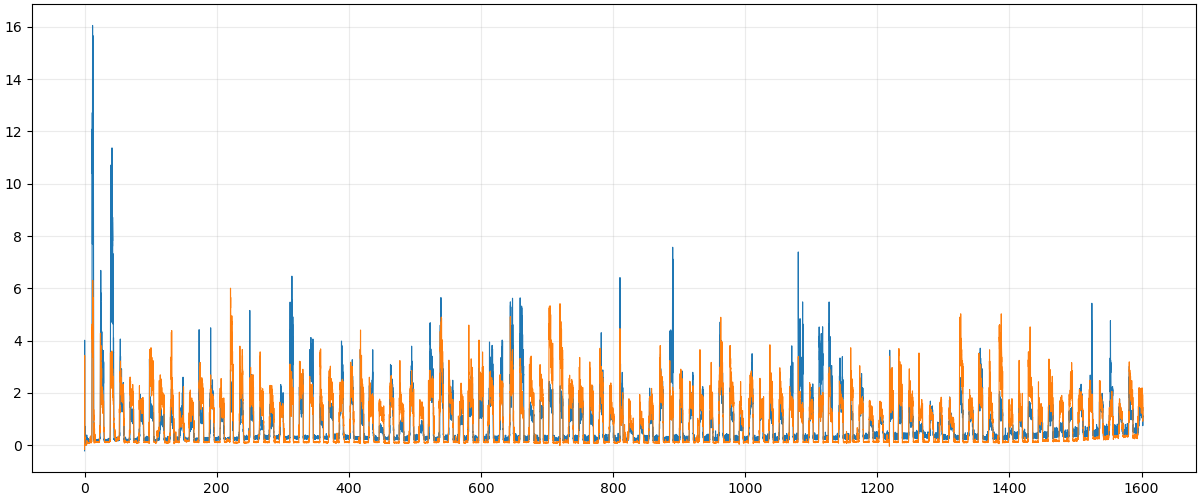

In [8]:
annotator.show_plots()

In [9]:
annotator.finish()

len(annotator.points)

212

In [10]:
with open(tmp_folder / str(participant_id) / 'emg_events.json', 'w') as json_file:
    json.dump(
        {
            'points': annotator.points,
            'anomaly_points': annotator.anomaly_points
        },
        json_file
    )

---

In [7]:
annotator = SignalAnnotator(
    ts=lia_timestamps,
    signal=lia_norm_data,
    sampling_rate=1024
)

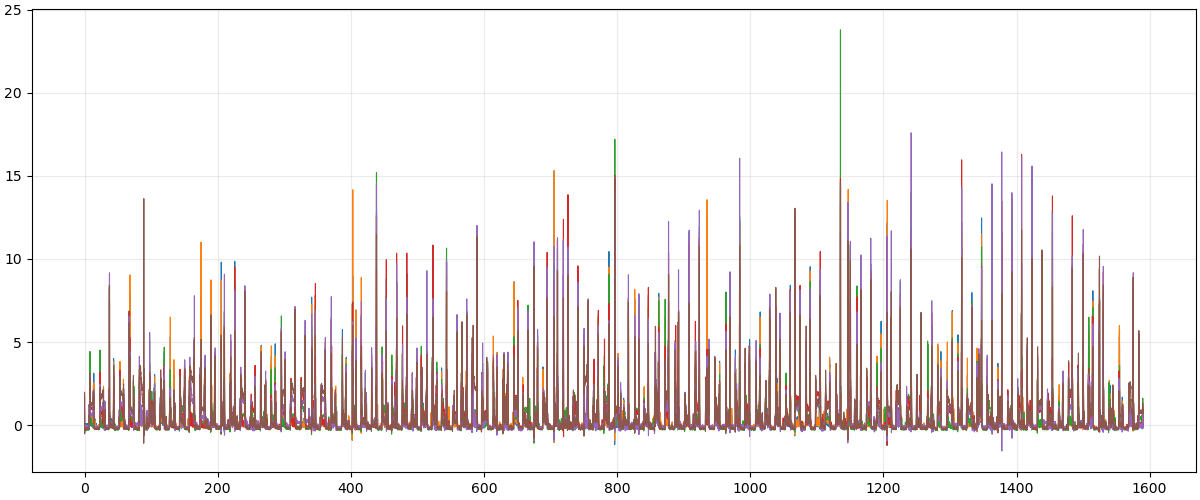

In [8]:
annotator.show_plots()

In [9]:
annotator.finish()

len(annotator.points)

105

In [10]:
with open(tmp_folder / str(participant_id) / 'glove_events.json', 'w') as json_file:
    json.dump(
        {
            'points': annotator.points,
            'anomaly_points': annotator.anomaly_points
        },
        json_file
    )